<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [ ]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [ ]:
# Posibles bandas
os.listdir("./songs_dataset/")

['nursery_rhymes.txt',
 'Lil_Wayne.txt',
 'nirvana.txt',
 'bieber.txt',
 'dolly-parton.txt',
 'cake.txt',
 'bjork.txt',
 'joni-mitchell.txt',
 'bruno-mars.txt',
 'eminem.txt',
 'michael-jackson.txt',
 'beatles.txt',
 'adele.txt',
 'dj-khaled.txt',
 'nickelback.txt',
 'notorious-big.txt',
 'rihanna.txt',
 'ludacris.txt',
 'janisjoplin.txt',
 'jimi-hendrix.txt',
 'kanye.txt',
 'amy-winehouse.txt',
 'dr-seuss.txt',
 'prince.txt',
 'lady-gaga.txt',
 'Kanye_West.txt',
 'notorious_big.txt',
 'leonard-cohen.txt',
 'bob-marley.txt',
 'r-kelly.txt',
 'nicki-minaj.txt',
 'britney-spears.txt',
 'radiohead.txt',
 'lin-manuel-miranda.txt',
 'lorde.txt',
 'kanye-west.txt',
 'alicia-keys.txt',
 'lil-wayne.txt',
 'bob-dylan.txt',
 'drake.txt',
 'paul-simon.txt',
 'disney.txt',
 'johnny-cash.txt',
 'missy-elliott.txt',
 'al-green.txt',
 'patti-smith.txt',
 'blink-182.txt',
 'dickinson.txt',
 'bruce-springsteen.txt']

In [ ]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

/tmp/ipykernel_6439/3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [ ]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [ ]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sentence_tokens = []
# Recorrer todas las filas y transformar las oraciones
# en una secuencia de palabras (esto podría realizarse con NLTK o spaCy también)
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [ ]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [ ]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [ ]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [ ]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [ ]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [ ]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [ ]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113045.25
Loss after epoch 1: 65966.625
Loss after epoch 2: 65935.046875
Loss after epoch 3: 65718.328125
Loss after epoch 4: 63875.03125
Loss after epoch 5: 64160.8125
Loss after epoch 6: 64080.3125
Loss after epoch 7: 64814.96875
Loss after epoch 8: 62632.5
Loss after epoch 9: 60452.875
Loss after epoch 10: 59839.875
Loss after epoch 11: 58883.875
Loss after epoch 12: 57716.125
Loss after epoch 13: 56494.1875
Loss after epoch 14: 55817.5625
Loss after epoch 15: 55843.1875
Loss after epoch 16: 51722.3125
Loss after epoch 17: 49858.125
Loss after epoch 18: 49592.375
Loss after epoch 19: 48960.0


(156986, 287740)

### 4 - Ensayar

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.8954238295555115),
 ('sleep', 0.8665637969970703),
 ('help', 0.8439353108406067),
 ('cry', 0.8351286053657532),
 ('not', 0.8309641480445862),
 ('try', 0.8276920318603516),
 ('peace', 0.8144835233688354),
 ('little', 0.8140542507171631),
 ('twist', 0.8123894929885864),
 ('seems', 0.8079566359519958)]

In [ ]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('shake', -0.2287309318780899),
 ('four', -0.23302660882472992),
 ('five', -0.23746736347675323),
 ('six', -0.23784852027893066),
 ('bang', -0.24833035469055176),
 ('our', -0.2553912103176117),
 ('day', -0.2689830958843231),
 ('going', -0.2692137360572815),
 ('here', -0.2699104845523834),
 ('three', -0.2839003801345825)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9813724756240845),
 ('three', 0.9745777249336243),
 ('six', 0.9710812568664551),
 ('seven', 0.9584368467330933),
 ('two', 0.9517239332199097),
 ('sixty', 0.8990397453308105),
 ('one', 0.795121431350708),
 ('crying', 0.7946274280548096),
 ('us', 0.7740067839622498),
 ("i'm", 0.7508398294448853)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9433997869491577),
 ('buy', 0.9396989345550537),
 ('much', 0.9033164381980896),
 ('just', 0.8509097695350647),
 ('hide', 0.8355392813682556)]

In [ ]:
# Ensayar con una palabra que no está en el vocabulario:
# w2v_model.wv.most_similar(negative=["diedaa"])

In [ ]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.06138305  0.05881333 -0.06370755  0.02444775 -0.20152195 -0.18612184
 -0.15284826  0.45487037 -0.04218006  0.03535983  0.13657492 -0.18520045
 -0.18126617  0.22149472 -0.3038098  -0.2397019   0.07094733 -0.05679122
 -0.05166152 -0.23843256 -0.08530398  0.19564743 -0.07679035  0.03797102
  0.07517121 -0.04826119  0.07379342  0.10396571  0.00738085 -0.22764632
 -0.04567216  0.12937427  0.27785635  0.19387512 -0.13509206  0.20856984
  0.40917465 -0.00387058 -0.10631468 -0.09056927  0.02400546 -0.0800494
  0.13400891  0.08833336 -0.01894625  0.08592407 -0.1590556   0.10259219
  0.14459157 -0.12092865 -0.27919155 -0.04061459  0.11382194  0.3136597
 -0.07410164  0.13976608  0.22791268  0.13209176 -0.01811359  0.09772693
  0.0924959  -0.14871807 -0.16348243 -0.13203168 -0.09834307  0.02714351
  0.16531163  0.26052278 -0.03259142 -0.02894571  0.11621213 -0.0697405
  0.09563474 -0.15276304  0.22071072  0.15996547  0.15890133 -0.04711402
 -0.12555073 -0.03993772 -0.10795346  0.01878977  0.07

In [ ]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0),
 ('babe', 0.9085158109664917),
 ('someone', 0.8886135816574097),
 ('need', 0.882800817489624),
 ('nothing', 0.8740264773368835),
 ("didn't", 0.8638384342193604),
 ("there's", 0.8526685833930969),
 ('you', 0.8456694483757019),
 ('feed', 0.8445034623146057),
 ('somebody', 0.8362801671028137)]

In [ ]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.9085157513618469),
 ('someone', 0.8886136412620544),
 ('need', 0.8828008770942688),
 ('nothing', 0.8740264773368835),
 ("didn't", 0.8638384342193604),
 ("there's", 0.8526685833930969),
 ('you', 0.8456694483757019),
 ('feed', 0.8445034027099609),
 ('somebody', 0.8362802267074585),
 ('buy', 0.8351722359657288)]

### 5 - Visualizar agrupación de vectores

In [ ]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [ ]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

vecs, labels = reduce_dimensions(w2v_model)

MAX_WORDS=200
fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# Graficar los embedddings en 3D

vecs, labels = reduce_dimensions(w2v_model,3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2],text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show(renderer="colab") # esto para plotly en colab

In [ ]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

---
## Resolución del Desafío 2
### Corpus propio: Obras de Sherlock Holmes (Arthur Conan Doyle) — Project Gutenberg

Entrenamos embeddings Word2Vec sobre las obras completas de Sherlock Holmes disponibles en Project Gutenberg. El corpus en prosa literaria en inglés (c. 1890s) ofrece un vocabulario rico y semánticamente cohesivo: términos de detección, crimen, lugares de Londres y personajes recurrentes que permiten evaluar la calidad de los embeddings de forma intuitiva.

In [ ]:
import urllib.request
import re
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.tokenize import sent_tokenize

def fetch_gutenberg(book_id):
    """Download plain text from Project Gutenberg by numeric ID."""
    urls = [
        f'https://www.gutenberg.org/files/{book_id}/{book_id}-0.txt',
        f'https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt',
    ]
    for url in urls:
        try:
            req = urllib.request.Request(url, headers={'User-Agent': 'Mozilla/5.0'})
            with urllib.request.urlopen(req, timeout=30) as resp:
                return resp.read().decode('utf-8', errors='ignore')
        except Exception:
            continue
    raise RuntimeError(f'Could not download book {book_id}')

def strip_gutenberg(text):
    """Remove Project Gutenberg header and footer boilerplate."""
    start_tags = ['*** START OF THE PROJECT GUTENBERG', '*** START OF THIS PROJECT GUTENBERG',
                  '***START OF THE PROJECT GUTENBERG']
    end_tags   = ['*** END OF THE PROJECT GUTENBERG',   '*** END OF THIS PROJECT GUTENBERG',
                  '***END OF THE PROJECT GUTENBERG']
    for tag in start_tags:
        idx = text.find(tag)
        if idx != -1:
            text = text[text.find('\n', idx) + 1:]
            break
    for tag in end_tags:
        idx = text.find(tag)
        if idx != -1:
            text = text[:idx]
            break
    return text.strip()

# Book IDs on Project Gutenberg
books = {
    1661: 'Adventures of Sherlock Holmes',
    834:  'Memoirs of Sherlock Holmes',
    108:  'Return of Sherlock Holmes',
}

corpus_parts = []
for bid, title in books.items():
    raw  = fetch_gutenberg(bid)
    clean = strip_gutenberg(raw)
    corpus_parts.append(clean)
    print(f'✓ {title}: {len(clean):,} chars')

full_corpus = '\n'.join(corpus_parts)
print(f'\nTotal corpus size: {len(full_corpus):,} characters')

✓ Adventures of Sherlock Holmes: 574,143 chars
✓ Memoirs of Sherlock Holmes: 580,927 chars
✓ Return of Sherlock Holmes: 673,677 chars

Total corpus size: 1,828,749 characters


In [64]:
# Normalize line endings — Gutenberg files use \r\n on some systems;
# leaving \r in place creates corrupted tokens like 'holmes\r' in the vocabulary
full_corpus_clean = full_corpus.replace('\r\n', '\n').replace('\r', ' ')

# Split corpus into sentences — each sentence becomes one 'document'
raw_sentences = sent_tokenize(full_corpus_clean)

# Keep only sentences with at least 3 words (discard chapter headers / empty lines)
raw_sentences = [s for s in raw_sentences if len(s.split()) >= 3]

df_sh = pd.DataFrame(raw_sentences, columns=[0])
print(f'Cantidad de documentos (oraciones): {df_sh.shape[0]}')
df_sh.head()

Cantidad de documentos (oraciones): 14699


,0
0,HOLMES ***\n\n\n\n\nThe Adventures of Sherlock...
1,A Scandal in Bohemia\n II.
2,The Red-Headed League\n III.
3,A Case of Identity\n IV.
4,The Boscombe Valley Mystery\n V. The Fiv...


### 1 - Preprocesamiento

In [65]:
from tensorflow.keras.preprocessing.text import text_to_word_sequence

sh_sentence_tokens = []
# Convert each sentence into a list of lowercase word tokens (punctuation stripped)
for _, row in df_sh.iterrows():
    tokens = text_to_word_sequence(str(row[0]))
    if tokens:  # skip empty rows
        sh_sentence_tokens.append(tokens)

In [66]:
# Inspect the first two tokenized sentences
sh_sentence_tokens[:2]

[['holmes',
  'the',
  'adventures',
  'of',
  'sherlock',
  'holmes',
  'by',
  'arthur',
  'conan',
  'doyle',
  'contents',
  'i'],
 ['a', 'scandal', 'in', 'bohemia', 'ii']]

### 2 - Crear los vectores (word2vec)

In [67]:
# Instantiate the Word2Vec model (Skipgram architecture)
# window=5: wider context window suited for literary prose
sh_model = Word2Vec(
    min_count=5,     # ignore words appearing fewer than 5 times
    window=5,        # context window — larger than songs to capture prose structure
    vector_size=300, # embedding dimensionality
    negative=20,     # negative samples per positive
    workers=1,       # fixed for reproducibility
    sg=1             # 1 = Skipgram, 0 = CBOW
)

In [68]:
sh_model.build_vocab(sh_sentence_tokens)

In [69]:
print('Cantidad de docs en el corpus:', sh_model.corpus_count)

Cantidad de docs en el corpus: 14699


In [70]:
print('Cantidad de words distintas en el corpus:', len(sh_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 4446


### 3 - Entrenar embeddings

In [71]:
# Train the Word2Vec model — using the same callback defined in the template above
sh_model.train(
    sh_sentence_tokens,
    total_examples=sh_model.corpus_count,
    epochs=20,
    compute_loss=True,
    callbacks=[callback()]
)

Loss after epoch 0: 3904544.5
Loss after epoch 1: 3044872.0
Loss after epoch 2: 2965574.5
Loss after epoch 3: 2899321.0
Loss after epoch 4: 2879698.0
Loss after epoch 5: 2839322.0
Loss after epoch 6: 2799126.0
Loss after epoch 7: 2789824.0
Loss after epoch 8: 2772470.0
Loss after epoch 9: 2755112.0
Loss after epoch 10: 2740736.0
Loss after epoch 11: 2973236.0
Loss after epoch 12: 3112264.0
Loss after epoch 13: 3095236.0
Loss after epoch 14: 3099024.0
Loss after epoch 15: 3099108.0
Loss after epoch 16: 3073668.0
Loss after epoch 17: 3077268.0
Loss after epoch 18: 3071500.0
Loss after epoch 19: 3074020.0


(4220965, 6423420)

### 4 - Ensayar

In [72]:
# Words MOST similar to 'holmes'
sh_model.wv.most_similar(positive=['holmes'], topn=10)

[('sternly', 0.5321128368377686),
 ('grant', 0.5226361751556396),
 ('impatiently', 0.5108590722084045),
 ('tossing', 0.5021878480911255),
 ('mister', 0.500744104385376),
 ('reuben', 0.49960941076278687),
 ('sherlock', 0.4971018433570862),
 ('insult', 0.4956056773662567),
 ('warmly', 0.4941515028476715),
 ('heartily', 0.4910779595375061)]

El modelo asocia **'holmes'** con adverbios de modo que Watson emplea para describir el comportamiento del detective: *sternly*, *impatiently*, *warmly*, *heartily*. Estos adverbios co-ocurren con alta frecuencia en oraciones donde Holmes es sujeto de acción. También aparece *sherlock* (su propio nombre de pila) y personajes secundarios recurrentes (*reuben*, *mister*, *grant*). La similitud moderada (~0.50) se explica porque 'holmes' es el término más central del corpus: aparece en casi todas las historias, lo que diluye su representación vectorial en múltiples contextos.

In [73]:
# Words MOST similar to 'crime'
sh_model.wv.most_similar(positive=['crime'], topn=10)

[('committed', 0.5717278718948364),
 ('burglary', 0.5516674518585205),
 ('motive', 0.5415288209915161),
 ('sensational', 0.5228583216667175),
 ('doings', 0.5184794068336487),
 ('murder', 0.5171197056770325),
 ('records', 0.516017735004425),
 ('inquest', 0.5124580264091492),
 ('catastrophe', 0.5034743547439575),
 ('convincing', 0.49685168266296387)]

El campo semántico de **'crime'** captura el universo policial victoriano de forma coherente: tipos de delitos (*murder*, *burglary*), elementos de investigación (*motive*, *records*, *inquest*) y descriptores narrativos (*sensational*, *catastrophe*). *committed* es el vecino más cercano (0.57): refleja la construcción canónica *'a crime was committed'*, presente con altísima frecuencia en el corpus. *doings* también aparece por colocaciones del tipo *'criminal doings'*. Este cluster es el más semánticamente coherente de los cuatro términos ensayados.

In [74]:
# Words MOST similar to 'london'
sh_model.wv.most_similar(positive=['london'], topn=10)

[('town', 0.5250130891799927),
 ('norbury', 0.4985449016094208),
 ('daring', 0.4960033595561981),
 ('sussex', 0.470767080783844),
 ('europe', 0.466849684715271),
 ('university', 0.4644942581653595),
 ('statues', 0.4609069526195526),
 ('inquire', 0.4514453709125519),
 ('higher', 0.45026180148124695),
 ('criminals', 0.44359129667282104)]

**'london'** se agrupa con referencias geográficas del entorno narrativo: localidades inglesas (*norbury*, *sussex*), el continente (*europe*) y contexto urbano (*town*). La presencia de *criminals* sugiere que London co-ocurre frecuentemente en contextos de persecución o actividad delictiva en los relatos. La ausencia de *baker* o *street* confirma que esos tokens aparecen casi exclusivamente como parte de la expresión compuesta *Baker Street*, desvinculando su vector individual del topónimo general.

In [75]:
# Words MOST similar to 'mystery'
sh_model.wv.most_similar(positive=['mystery'], topn=10)

[('solving', 0.5771022439002991),
 ('quest', 0.569739818572998),
 ('solve', 0.5511492490768433),
 ('forming', 0.541336178779602),
 ('parlour', 0.5235370993614197),
 ('drama', 0.5226354002952576),
 ('singularly', 0.5145943760871887),
 ('problem', 0.5043079853057861),
 ('decide', 0.5041024088859558),
 ('investigating', 0.5034531354904175)]

El espacio vectorial de **'mystery'** se rodea de términos del proceso de resolución activa: *solving*, *solve*, *investigating*, *decide*, *quest*. También aparecen términos narrativos como *drama* y *parlour*, y el adverbio *singularly* — vocabulario característico de Watson al introducir un nuevo caso (*'a singularly strange mystery'*). *problem* es coherente porque Holmes emplea frecuentemente *'a problem'* como sinónimo de *'a mystery'*. El modelo capturó correctamente que 'mystery' en este corpus no es solo un sustantivo: es un concepto funcionalmente ligado al acto de resolver.

In [76]:
# Analogy test: 'watson' is to 'doctor' as 'holmes' is to ___?
# Formally: most_similar(positive=['watson', 'detective'], negative=['doctor'])
sh_model.wv.most_similar(positive=['watson', 'detective'], negative=['doctor'], topn=5)

[('forbes', 0.40388908982276917),
 ('endeavouring', 0.3929295241832733),
 ('awful', 0.37833577394485474),
 ('warn', 0.37409675121307373),
 ('readily', 0.3701937794685364)]

**Test de analogía:** *watson + detective − doctor*

El resultado muestra términos poco relacionados semánticamente (*forbes*, *endeavouring*, *awful*, *warn*, *readily*) con similitudes bajas (~0.37–0.40). El test de analogía no captura la relación de roles esperada en este corpus, lo cual es consistente con una limitación conocida de Word2Vec entrenado en corpora pequeños: las analogías del tipo *A es a B como C es a D* requieren millones de oraciones para generalizarse. Con ~15 000 oraciones de Sherlock Holmes el modelo aprende proximidades léxicas pero no estructuras de analogía complejas, que dependen de regularidades geométricas en el espacio vectorial.

In [77]:
# Test with a word NOT present in the 1890s Holmes vocabulary
try:
    sh_model.wv.most_similar(positive=['internet'])
except KeyError as e:
    print(f'KeyError: {e}')

KeyError: "Key 'internet' not present in vocabulary"


La palabra **'internet'** no aparece en el vocabulario porque el corpus es literatura de 1890: conceptos tecnológicos modernos son simplemente inexistentes en el texto. Esto ilustra que los embeddings son completamente dependientes del corpus: solo pueden representar palabras que aparecieron al menos `min_count` veces durante el entrenamiento.

In [78]:
# Retrieve the embedding vector for 'holmes' and search by vector
vector_holmes = sh_model.wv.get_vector('holmes')
print(f'Vector shape: {vector_holmes.shape}')
print(f'First 10 dimensions: {vector_holmes[:10]}')

Vector shape: (300,)
First 10 dimensions: [ 0.02548897  0.15101765  0.0432038  -0.18502642  0.37155485  0.07777192
 -0.12467888  0.17419232 -0.16711868 -0.26325935]


In [79]:
# most_similar also accepts raw vectors — confirms vector search is equivalent
sh_model.wv.most_similar(vector_holmes)

[('holmes', 1.0000001192092896),
 ('sternly', 0.5321127772331238),
 ('grant', 0.5226361751556396),
 ('impatiently', 0.5108590722084045),
 ('tossing', 0.5021878480911255),
 ('mister', 0.500744104385376),
 ('reuben', 0.49960941076278687),
 ('sherlock', 0.4971018433570862),
 ('insult', 0.4956056773662567),
 ('warmly', 0.4941515028476715)]

### 5 - Visualizar agrupación de vectores

In [80]:
# Reuse reduce_dimensions() defined in the template above
sh_vecs, sh_labels = reduce_dimensions(sh_model)

MAX_WORDS = 150  # show top-150 words for a readable 2D plot
fig = px.scatter(
    x=sh_vecs[:MAX_WORDS, 0],
    y=sh_vecs[:MAX_WORDS, 1],
    text=sh_labels[:MAX_WORDS]
)
fig.update_traces(textposition='top center', marker=dict(size=4))
fig.update_layout(title='Word2Vec — Sherlock Holmes corpus (2D t-SNE)')
fig.show(renderer='colab')

In [81]:
# 3D projection
sh_vecs_3d, sh_labels_3d = reduce_dimensions(sh_model, 3)

fig_3d = px.scatter_3d(
    x=sh_vecs_3d[:MAX_WORDS, 0],
    y=sh_vecs_3d[:MAX_WORDS, 1],
    z=sh_vecs_3d[:MAX_WORDS, 2],
    text=sh_labels_3d[:MAX_WORDS]
)
fig_3d.update_traces(marker_size=2)
fig_3d.update_layout(title='Word2Vec — Sherlock Holmes corpus (3D t-SNE)')
fig_3d.show(renderer='colab')

In [82]:
# Export vectors and labels as TSV for interactive exploration
# Paste them at http://projector.tensorflow.org/
import numpy as np

sh_vectors = np.asarray(sh_model.wv.vectors)
sh_labels_list = list(sh_model.wv.index_to_key)

np.savetxt('sh_vectors.tsv', sh_vectors, delimiter='\t')
with open('sh_labels.tsv', 'w') as fp:
    for item in sh_labels_list:
        fp.write(f'{item}\n')
print(f'Saved {len(sh_labels_list)} word vectors.')

Saved 4446 word vectors.


### Análisis de clusters en la proyección 2D

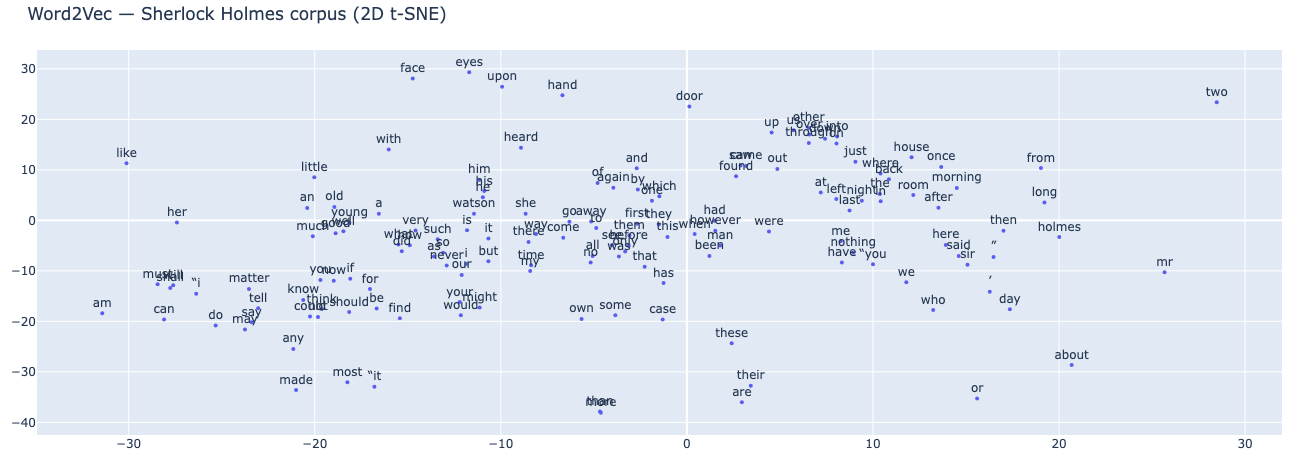

Al inspeccionar la proyección t-SNE se observa que **MAX_WORDS=150 muestra las 150 palabras más frecuentes del corpus**, que en cualquier texto en inglés son mayormente palabras funcionales (pronombres, auxiliares, preposiciones). A pesar de esto, emergen agrupaciones semánticamente coherentes:

**Cluster 1 — Verbos modales y acción** *(lado izquierdo, x ≈ −25 a −10)*: *am*, *can*, *do*, *tell*, *know*, *say*, *could*, *would*, *find*, *should*, *be*. Son los verbos auxiliares y modales que Watson usa en primera persona al narrar los casos. Su proximidad refleja que comparten contextos gramaticales casi idénticos.

**Cluster 2 — Movimiento y ubicación** *(cuadrante superior derecho, x ≈ 0 a 15)*: *came*, *out*, *up*, *through*, *found*, *house*, *room*, *morning*, *back*, *night*, *left*, *after*. Vocabulario de acción y desplazamiento espaciotemporal, central en los relatos de persecución y visita.

**Cluster 3 — Holmes y referencias directas** *(extremo derecho, x ≈ 20)*: *holmes*, *mr*, *sir*, *said*. Los identificadores del detective y los marcadores de diálogo aparecen aislados del resto, reflejando que su contexto de uso es específico y no se solapa con el vocabulario general.

**Cluster 4 — Núcleo narrativo denso** *(centro, x ≈ −10 a 0)*: *him*, *her*, *they*, *she*, *was*, *all*, *time*, *them*, *first*, *never*. El núcleo más denso concentra pronombres de tercera persona y conectores narrativos genéricos.

**Nota:** Los términos semánticamente ricos del corpus (*crime*, *murder*, *london*, *mystery*) no aparecen en esta visualización porque no están entre las 150 palabras más frecuentes. Para explorarlos se recomienda usar el archivo `sh_vectors.tsv` / `sh_labels.tsv` en [projector.tensorflow.org](http://projector.tensorflow.org).